# Level 2 — Task 1: Restaurant Ratings Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_excel("C:/Users/Surya/Downloads/Dataset .xlsx")

In [3]:
print(df.head())
print(df.columns)

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [4]:
print(df['Aggregate rating'].describe())

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


In [5]:
df = df.dropna(subset=['Aggregate rating', 'Votes'])

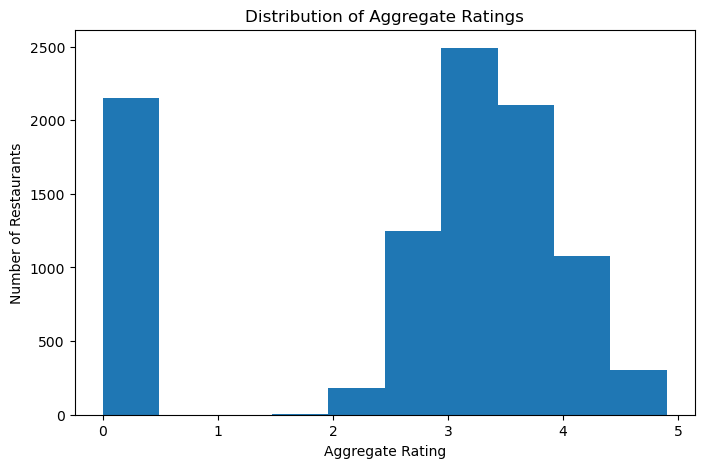

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df['Aggregate rating'], bins=10)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.show()

In [7]:
bins = [0, 1, 2, 3, 4, 5]

labels = ['0-1', '1-2', '2-3', '3-4', '4-5']

df['Rating Range'] = pd.cut(
    df['Aggregate rating'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [8]:
rating_range_counts = df['Rating Range'].value_counts().sort_index()

print(rating_range_counts)

Rating Range
0-1    2148
1-2      10
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64


In [9]:
most_common_range = rating_range_counts.idxmax()

print("\nMost Common Rating Range:")
print(most_common_range)


Most Common Rating Range:
3-4


In [10]:
average_votes = df['Votes'].mean()

print("\nAverage Number of Votes:")
print(average_votes)


Average Number of Votes:
156.909747670401


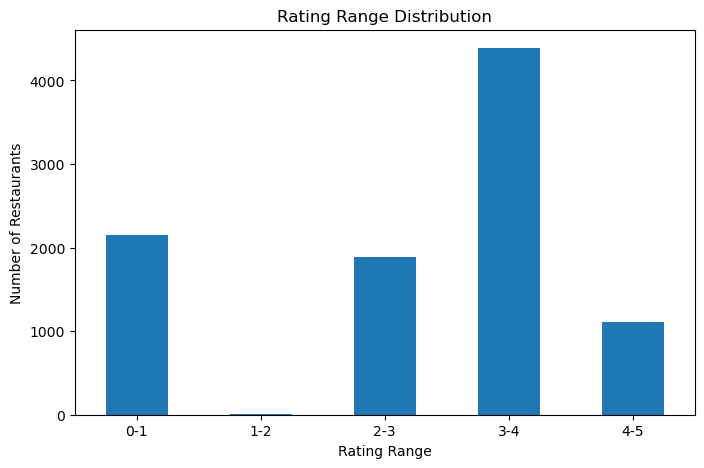

In [11]:
plt.figure(figsize=(8,5))

rating_range_counts.plot(kind='bar')

plt.title("Rating Range Distribution")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)

plt.show()

# Level 2 → Task 2: Cuisine Combination Analysis

In [12]:
df= pd.read_excel("C:/Users/Surya/Downloads/Dataset .xlsx")

In [13]:
print(df.head())
print(df.columns)

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [14]:
df = df.dropna(subset=['Cuisines', 'Aggregate rating'])

In [15]:
combo_counts = df['Cuisines'].value_counts()

print("Most Common Cuisine Combinations:")
print(combo_counts.head(10))

Most Common Cuisine Combinations:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [16]:
combo_ratings = df.groupby('Cuisines')['Aggregate rating'].mean()

In [17]:
combo_ratings = combo_ratings.sort_values(ascending=False)

print("\nTop Rated Cuisine Combinations:")
print(combo_ratings.head(10))


Top Rated Cuisine Combinations:
Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64


In [18]:
combo_frequency = df['Cuisines'].value_counts()

In [19]:
popular_combos = combo_frequency[combo_frequency > 10].index

In [20]:
popular_combo_ratings = df[df['Cuisines'].isin(popular_combos)]

popular_combo_ratings = popular_combo_ratings.groupby('Cuisines')['Aggregate rating'].mean()

popular_combo_ratings = popular_combo_ratings.sort_values(ascending=False)

print("\nPopular Cuisine Combinations with Highest Ratings:")
print(popular_combo_ratings.head(10))


Popular Cuisine Combinations with Highest Ratings:
Cuisines
Modern Indian       4.345455
Indian              4.250000
Seafood             4.114286
Thai                4.100000
American, Burger    4.076923
Japanese, Sushi     4.044444
Pizza, Italian      3.668421
American            3.667742
Italian             3.657407
Italian, Pizza      3.637500
Name: Aggregate rating, dtype: float64


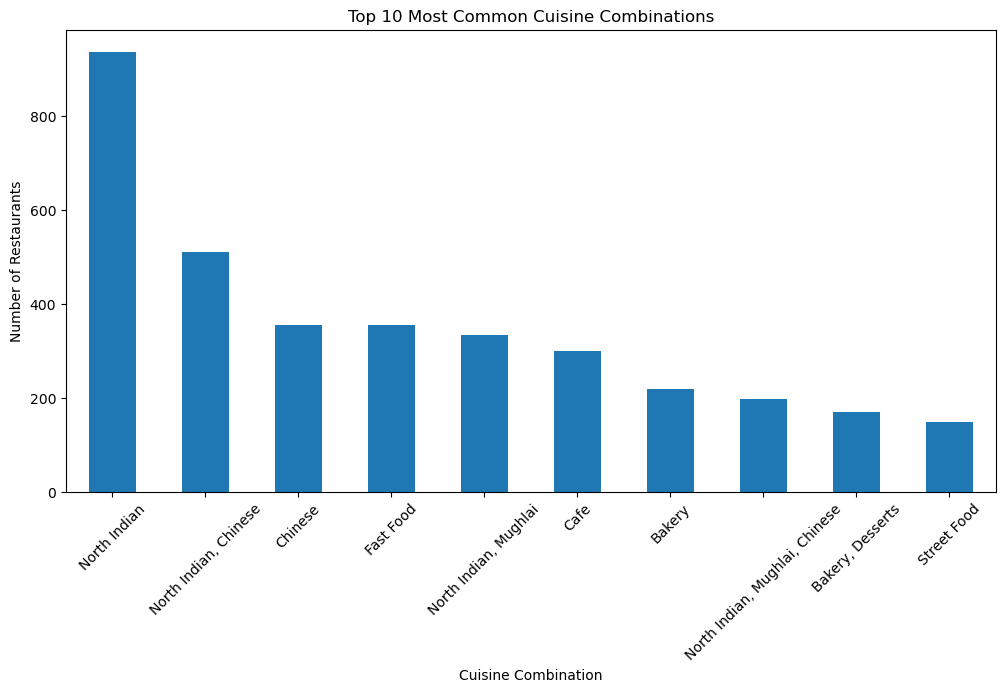

In [21]:
plt.figure(figsize=(12,6))

combo_counts.head(10).plot(kind='bar')

plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

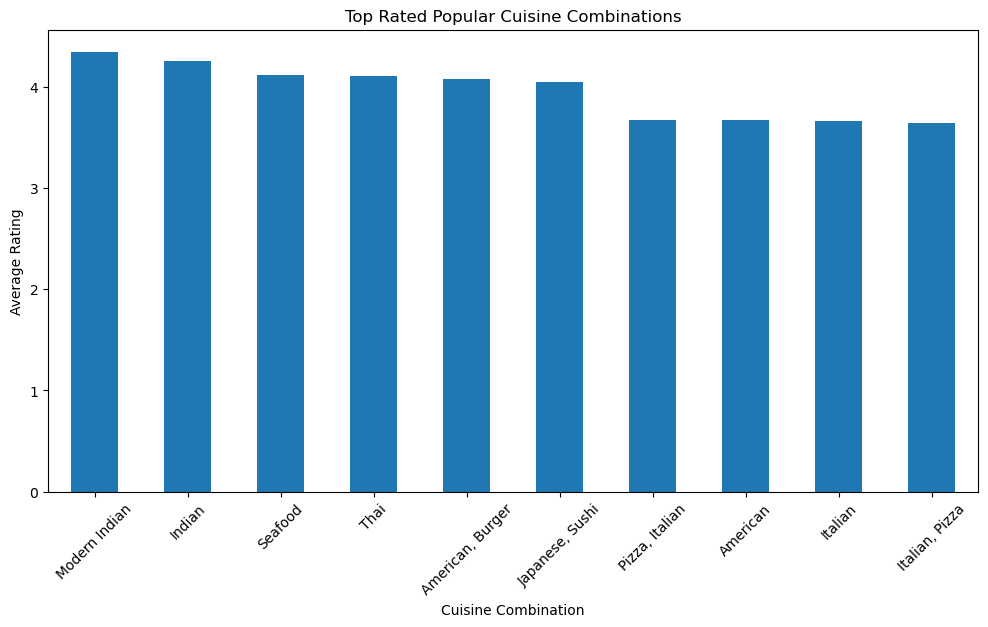

In [22]:
plt.figure(figsize=(12,6))

popular_combo_ratings.head(10).plot(kind='bar')

plt.title("Top Rated Popular Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

# Level 2 → Task 3: Geographic Analysis

In [24]:
pip install folium


   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

In [26]:
df= pd.read_excel("C:/Users/Surya/Downloads/Dataset .xlsx")

In [27]:
df = df.dropna(subset=['Latitude', 'Longitude'])

In [28]:
map_center = [
    df['Latitude'].mean(),
    df['Longitude'].mean()
]

restaurant_map = folium.Map(
    location=map_center,
    zoom_start=5
)

In [29]:
marker_cluster = MarkerCluster().add_to(restaurant_map)

In [30]:
for index, row in df.iterrows():

    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        
        popup=f"""
        Restaurant: {row['Restaurant Name']}<br>
        City: {row['City']}
        """
        
    ).add_to(marker_cluster)

In [31]:
restaurant_map.save("restaurant_map.html")

# Level 2 → Task 4: Restaurant Chains Analysis

In [32]:
df= pd.read_excel("C:/Users/Surya/Downloads/Dataset .xlsx")

In [33]:
df = df.dropna(subset=[
    'Restaurant Name',
    'Aggregate rating',
    'Votes'
])

In [34]:
restaurant_counts = df['Restaurant Name'].value_counts()

In [35]:
chains = restaurant_counts[restaurant_counts > 1]

print("Restaurant Chains:")
print(chains.head(20))

Restaurant Chains:
Restaurant Name
Cafe Coffee Day        83
Domino's Pizza         79
Subway                 63
Green Chick Chop       51
McDonald's             48
Keventers              34
Pizza Hut              30
Giani                  29
Baskin Robbins         28
Barbeque Nation        26
Giani's                22
Barista                22
Dunkin' Donuts         22
Costa Coffee           20
Pind Balluchi          20
Wah Ji Wah             19
Twenty Four Seven      19
Pizza Hut Delivery     19
Sagar Ratna            19
Republic of Chicken    18
Name: count, dtype: int64


In [36]:
chain_data = df[df['Restaurant Name'].isin(chains.index)]

In [37]:
chain_ratings = chain_data.groupby(
    'Restaurant Name'
)['Aggregate rating'].mean()

chain_ratings = chain_ratings.sort_values(
    ascending=False
)

print("\nTop Rated Restaurant Chains:")
print(chain_ratings.head(10))


Top Rated Restaurant Chains:
Restaurant Name
Talaga Sampireun             4.900
Silantro Fil-Mex             4.850
AB's Absolute Barbecues      4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Dishoom                      4.600
Garota de Ipanema            4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64


In [38]:
chain_votes = chain_data.groupby(
    'Restaurant Name'
)['Votes'].mean()

chain_votes = chain_votes.sort_values(
    ascending=False
)

print("\nMost Popular Restaurant Chains:")
print(chain_votes.head(10))


Most Popular Restaurant Chains:
Restaurant Name
Truffles                     4841.000000
Joey's Pizza                 3903.500000
AB's - Absolute Barbecues    3350.000000
Big Chill                    2713.250000
Big Yellow Door              2503.666667
Out Of The Box               2450.000000
Saravana Bhavan              2412.666667
Olive Bistro                 1854.000000
Talaga Sampireun             1838.000000
SpiceKlub                    1825.500000
Name: Votes, dtype: float64


In [39]:
chain_analysis = chain_data.groupby(
    'Restaurant Name'
).agg({
    'Aggregate rating': 'mean',
    'Votes': 'mean'
})

chain_analysis = chain_analysis.sort_values(
    by='Aggregate rating',
    ascending=False
)

print("\nRestaurant Chain Analysis:")
print(chain_analysis.head(10))


Restaurant Chain Analysis:
                           Aggregate rating   Votes
Restaurant Name                                    
Talaga Sampireun                      4.900  1838.0
Silantro Fil-Mex                      4.850   682.0
AB's Absolute Barbecues               4.850  1575.5
AB's - Absolute Barbecues             4.825  3350.0
Naturals Ice Cream                    4.800  1547.0
Gymkhana                              4.700   164.0
The Cheesecake Factory                4.650  1505.0
Dishoom                               4.600   634.5
Garota de Ipanema                     4.600    29.5
Chili's                               4.580  1631.2


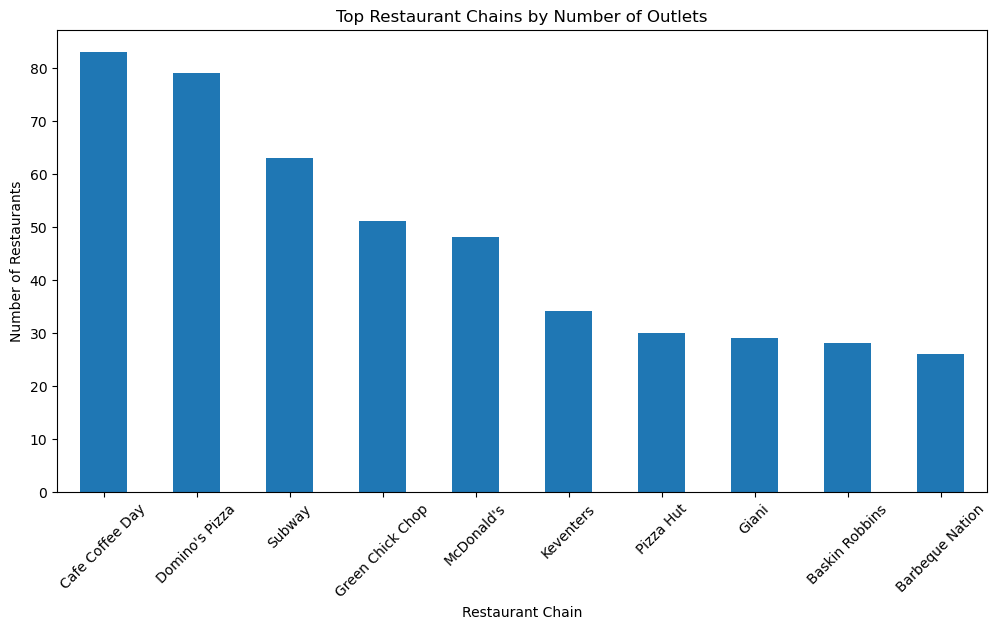

In [40]:
plt.figure(figsize=(12,6))

chains.head(10).plot(kind='bar')

plt.title("Top Restaurant Chains by Number of Outlets")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

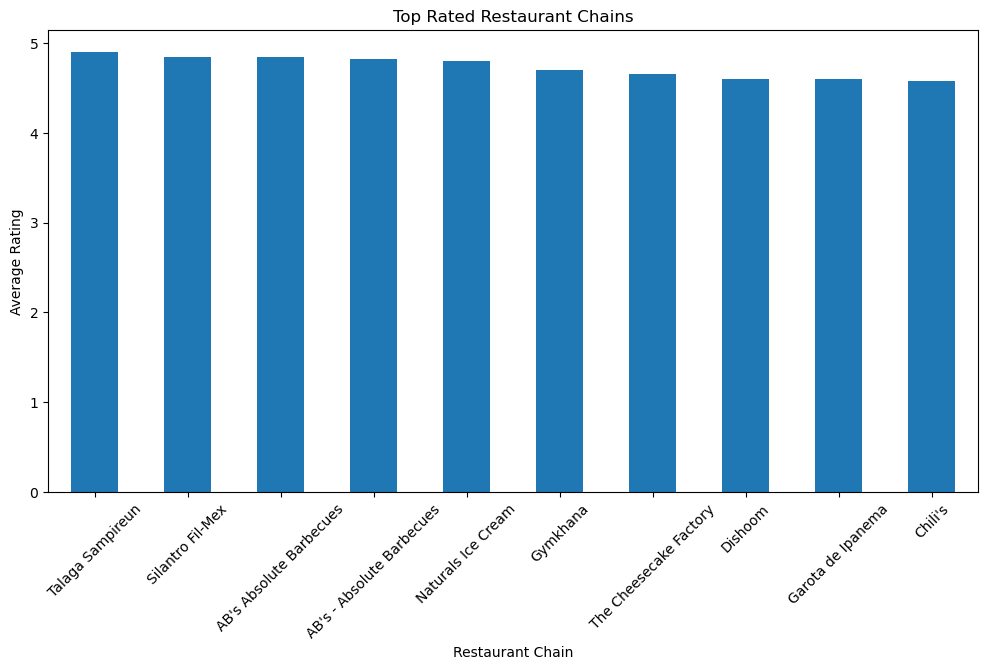

In [41]:
plt.figure(figsize=(12,6))

chain_ratings.head(10).plot(kind='bar')

plt.title("Top Rated Restaurant Chains")
plt.xlabel("Restaurant Chain")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()